### 0. ライブラリのインポート

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
import pickle

### 1. 作成済みモデルの読み込み

In [3]:
simple_LSTM = None

In [4]:
epochs = 30

In [5]:
# 保存したモデルを読み込む
with open(f"../model/simple_LSTM/GOOGL/simple_LSTM_{epochs}.pkl", "rb") as f:
    simple_LSTM = pickle.load(f)

### 仮説１：後追いしているだけならば，白色ガウスと予測線が重なる

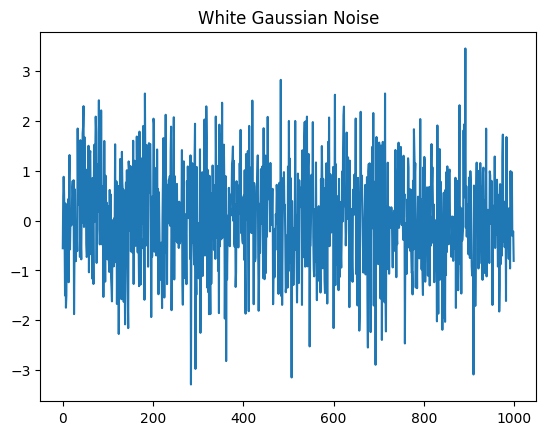

In [63]:
# 平均0, 標準偏差1 のホワイトガウスノイズを1000点生成
noise = np.random.normal(loc=0, scale=1, size=1000)

# 出力例
plt.plot(noise)
plt.title("White Gaussian Noise")
plt.show()

In [64]:
noise_train = noise[:800]
noise_test = noise[800:]
noise_train = noise_train.reshape(noise_train.shape[0], 1)
noise_test = noise_test.reshape(noise_test.shape[0], 1)

In [65]:
noise_test.shape

(200, 1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


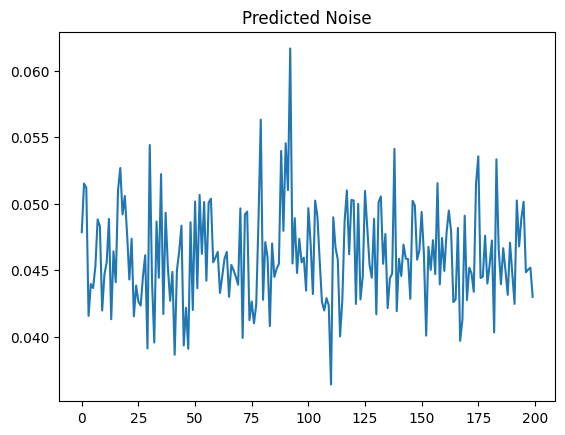

In [66]:
predicted_noise = simple_LSTM.predict(noise_test)
plt.plot(predicted_noise)
plt.title("Predicted Noise")
plt.show()

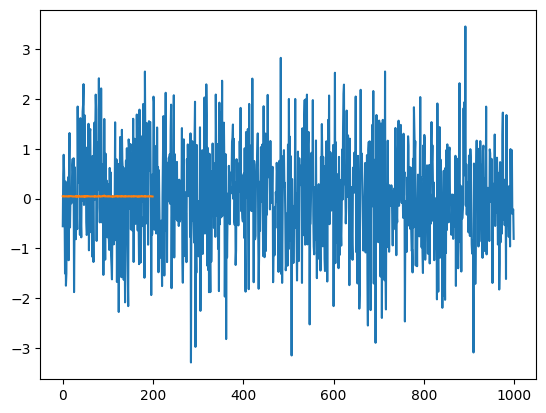

In [67]:
plt.plot(noise)
plt.plot(predicted_noise)
plt.show()

#### 仮説１の検証結果：平均・標準偏差がともに０の線が現れただけで，白色ガウスに対して過剰に反応することはなかった．

### 仮説２：ほかの銘柄についても予測が可能な場合，銘柄の特性を吸収していない

In [6]:
toyota = yf.download("7203.T", start="2004-08-19", end="2019-12-19", interval="1d")

C:\Users\togen\AppData\Local\Temp\ipykernel_2628\2993139428.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  toyota = yf.download("7203.T", start="2004-08-19", end="2019-12-19", interval="1d")
[*********************100%***********************]  1 of 1 completed


In [7]:
X = toyota[["Open"]].iloc[:800]
X = X.values
scaler = MinMaxScaler(feature_range=(0, 1))
X = scaler.fit_transform(X)

In [8]:
X_test = []
look_back = 60
for i in range(look_back, len(X)):
    X_test.append(X[i-look_back:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


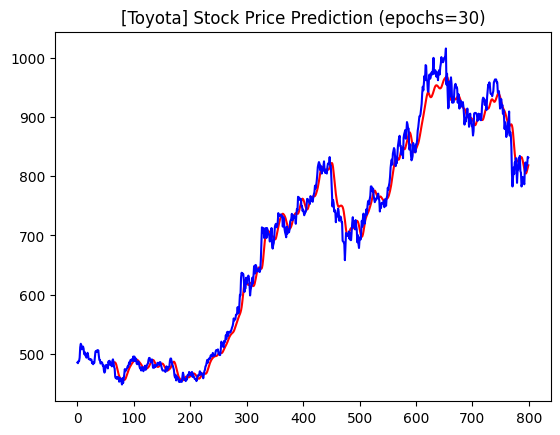

In [9]:
title = "[Toyota] Stock Price Prediction (epochs={})".format(epochs)
predicted_toyota = simple_LSTM.predict(X_test)
original_scale_predicted_toyota = scaler.inverse_transform(predicted_toyota)
original_scale_predicted_X = scaler.inverse_transform(X)
original_scale_predicted_toyota = np.concatenate((np.full(60, np.nan).reshape(-1, 1), original_scale_predicted_toyota))
plt.plot(original_scale_predicted_toyota, color="red")
plt.plot(original_scale_predicted_X, color="blue")
plt.title(title)
plt.savefig("../images/simple_LSTM/7203.T/{}.png".format(title))
plt.show()


#### 仮説２の検証結果：予測した線は遅行を示している．これは，真に有用とは言えない

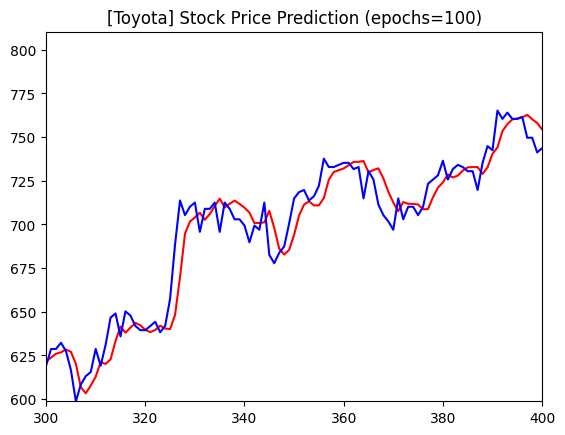

In [ ]:
title = "[Toyota] Stock Price Prediction (epochs={})".format(epochs)

lower_ylim = min(original_scale_predicted_toyota[~np.isnan(original_scale_predicted_toyota)][300:400].min(), original_scale_predicted_X[~np.isnan(original_scale_predicted_X)][300:400].min())
upper_ylim = max(original_scale_predicted_toyota[~np.isnan(original_scale_predicted_toyota)][300:400].max(), original_scale_predicted_X[~np.isnan(original_scale_predicted_X)][300:400].max())

plt.title(title)
plt.plot(original_scale_predicted_toyota, color="red")
plt.plot(original_scale_predicted_X, color="blue")
plt.ylim(lower_ylim, upper_ylim)
plt.xlim(300, 400)
plt.savefig(f"../images/simple_LSTM/7203.T/partial_zoom/{title}.png")
plt.show()

In [201]:
original_scale_predicted_X.shape

(800, 1)

In [202]:
window = 5
ma5 = np.convolve(original_scale_predicted_X[0], np.ones(window)/window, mode='valid')

In [212]:
original_scale_predicted_X

array([[ 485.659695  ],
       [ 484.48935594],
       [ 488.00025782],
       [ 488.00023397],
       [ 493.85158553],
       [ 511.40549073],
       [ 517.2568871 ],
       [ 514.9163582 ],
       [ 507.89475858],
       [ 509.06481297],
       [ 512.57561764],
       [ 509.06513241],
       [ 499.70284364],
       [ 503.21368079],
       [ 497.36235892],
       [ 497.36232486],
       [ 493.85153198],
       [ 496.19201   ],
       [ 502.04337218],
       [ 497.36234877],
       [ 491.51113892],
       [ 491.51090126],
       [ 490.34063721],
       [ 491.51103043],
       [ 490.34063721],
       [ 490.34063721],
       [ 484.4894646 ],
       [ 485.07096096],
       [ 482.71635844],
       [ 486.2482518 ],
       [ 485.07100587],
       [ 494.48987947],
       [ 503.90867997],
       [ 505.08596802],
       [ 503.90873662],
       [ 506.26339343],
       [ 503.90859261],
       [ 506.26330566],
       [ 496.8447658 ],
       [ 489.78059817],
       [ 489.7804224 ],
       [ 483.893

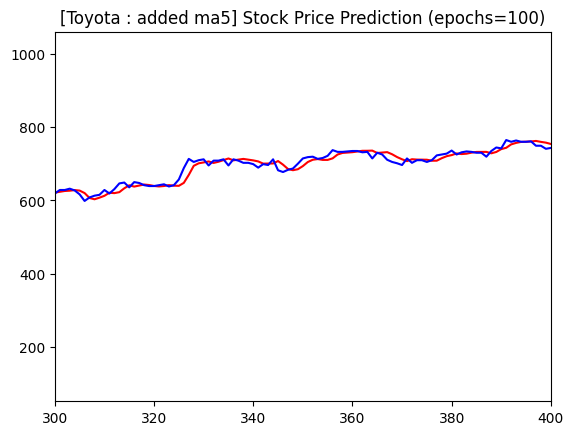

In [ ]:
title = "[Toyota : added ma5] Stock Price Prediction (epochs={})".format(epochs)

lower_ylim = min(original_scale_predicted_toyota[~np.isnan(original_scale_predicted_toyota)][300:400].min(), original_scale_predicted_X[~np.isnan(original_scale_predicted_X)][300:400].min())
upper_ylim = max(original_scale_predicted_toyota[~np.isnan(original_scale_predicted_toyota)][300:400].max(), original_scale_predicted_X[~np.isnan(original_scale_predicted_X)][300:400].max())

plt.title(title)
plt.plot(ma5.reshape(-1, 1), color="green")
plt.plot(original_scale_predicted_toyota, color="red")
plt.plot(original_scale_predicted_X, color="blue")
plt.ylim(lower_ylim, upper_ylim)
plt.xlim(300, 400)
plt.savefig(f"../images/simple_LSTM/7203.T/partial_zoom/added_ma5_{title}.png")
plt.show()

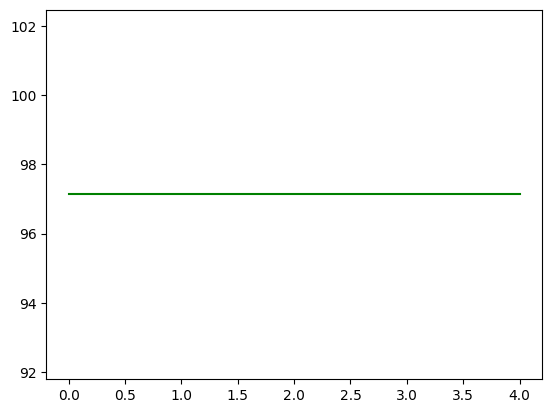

In [210]:
plt.plot(ma5.reshape(-1, 1), color="green")

### 相関を確認してラグを推定する

In [18]:
range_num = 30

In [19]:
Predictions = original_scale_predicted_toyota
Observations = original_scale_predicted_X

In [20]:
Observations_df = pd.DataFrame(Observations, columns=["Actual"]).reset_index(drop=True)
Predictions_df = pd.DataFrame(Predictions, columns=["Predicted"]).reset_index(drop=True)
shift_series = pd.concat(
    [Predictions_df.diff().shift(-1).shift(-i) for i in range(-range_num, range_num)], axis=1
)


In [21]:
shift_series = pd.concat(
    [Predictions_df.diff().shift(-1), shift_series, Observations_df.diff().shift(-1)], axis=1
)

In [22]:
shift_series.columns = ['Predicted'] + [f'Predicted_lag_{i}' for i in range(-range_num, range_num)] + ['Actual']

In [23]:
import scipy.stats as stats
import seaborn as sns
standardized_data = (stats.zscore(shift_series.dropna()))
lagged_df = pd.DataFrame(standardized_data, columns=['Predicted'] + [f'Predicted_lag_{i}' for i in range(-range_num, range_num)] + ['Actual'])
corr = lagged_df.corr()['Actual']

In [24]:
corr

Predicted           -0.032463
Predicted_lag_-30    0.047929
Predicted_lag_-29    0.021115
Predicted_lag_-28   -0.010915
Predicted_lag_-27   -0.023461
                       ...   
Predicted_lag_26     0.034844
Predicted_lag_27     0.028633
Predicted_lag_28     0.016032
Predicted_lag_29     0.013679
Actual               1.000000
Name: Actual, Length: 62, dtype: float64

Text(0, 0.5, 'cross-correlation')

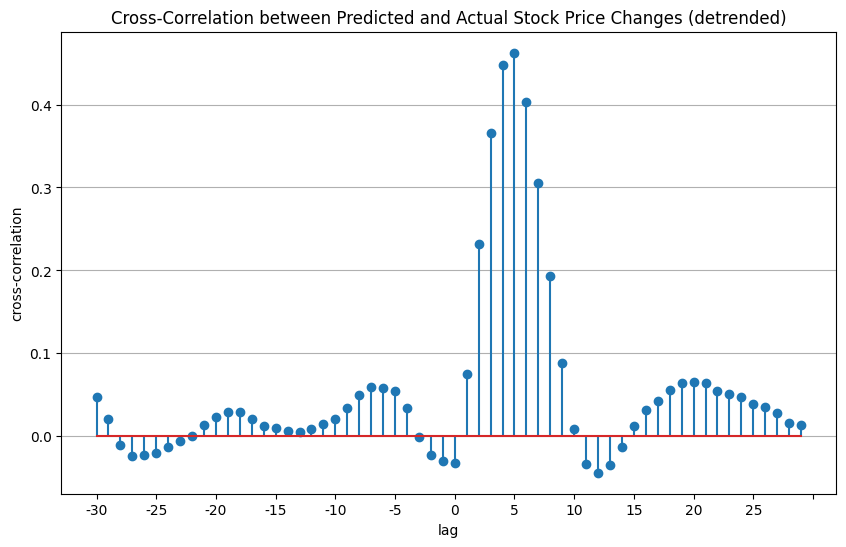

In [25]:
plt.figure(figsize=(10, 6))
plt.stem([f'{i}' for i in range(-range_num, range_num)], corr[1:-1])
plt.xlabel("lag")
plt.title("Cross-Correlation between Predicted and Actual Stock Price Changes (detrended)")
plt.grid(axis='y')
plt.xticks(range(0, len(corr), 5))
plt.ylabel("cross-correlation")